# Dependencies

Install Dependencies

In [1]:
# RL environment
!pip install -q gymnasium[atari]
!pip install -q ale-py

# Deep Learning
!pip install -q torch torchvision

# Experiment tracking
!pip install -q wandb

# Utilities
!pip install -q pyyaml matplotlib numpy opencv-python

Verify Installations

In [2]:
import torch
import gymnasium as gym
import numpy as np
import wandb
import ale_py

print("Torch:", torch.__version__)
print("Gymnasium:", gym.__version__)
print("NumPy:", np.__version__)
print("WandB:", wandb.__version__)
print("Ale-py:", ale_py.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cpu
Gymnasium: 1.3.0
NumPy: 2.0.2
WandB: 0.27.1
Ale-py: 0.12.0
CUDA available: False


Connect to Google Drive

In [3]:
# from google.colab import drive
# drive.mount('/content/gdrive/MyDrive/breakout_ddqn/checkpoint')


from google.colab import drive
import os

gdrive_path='/content/gdrive/MyDrive/breakout_ddqn/checkpoint'

# This will mount your google drive under 'MyDrive'
drive.mount('/content/gdrive', force_remount=True)
# In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))

Mounted at /content/gdrive
['DQN_Extensions', 'template.ipynb']


Clone github repo

In [4]:
!git clone https://github.com/sarthaknandwani/DQN_Extensions.git
%cd DQN_Extensions

fatal: destination path 'DQN_Extensions' already exists and is not an empty directory.
/content/gdrive/MyDrive/breakout_ddqn/checkpoint/DQN_Extensions


Login to WandB

In [5]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nandwanisarthak (nandwanisarthak-kiel-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Environment Setup

Quick breakout environment test

In [6]:
env = gym.make("ALE/Breakout-v5")

obs, info = env.reset()

print("Observation shape:", obs.shape)
print("Action space:", env.action_space)

Observation shape: (210, 160, 3)
Action space: Discrete(4)


Basic environment code

In [7]:
import gymnasium as gym

#create environment
env = gym.make("ALE/Breakout-v5")

#reset environment
obs, info = env.reset()

print("Observation shape:", obs.shape)
print("Observation dtype:", obs.dtype)

#action space
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)



Observation shape: (210, 160, 3)
Observation dtype: uint8
Action space: Discrete(4)
Number of actions: 4


In [8]:
#random actions
for step in range(10):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    print(
        f"Step: {step} | "
        f"Action: {action} | "
        f"Reward: {reward}"
    )

    if terminated or truncated:
        print("Episode finished, resetting environment")
        obs, info = env.reset()


# verify final observation
print("Final observation shape:", obs.shape)

# close environment
env.close()

Step: 0 | Action: 3 | Reward: 0.0
Step: 1 | Action: 0 | Reward: 0.0
Step: 2 | Action: 0 | Reward: 0.0
Step: 3 | Action: 3 | Reward: 0.0
Step: 4 | Action: 3 | Reward: 0.0
Step: 5 | Action: 1 | Reward: 0.0
Step: 6 | Action: 0 | Reward: 0.0
Step: 7 | Action: 1 | Reward: 0.0
Step: 8 | Action: 1 | Reward: 0.0
Step: 9 | Action: 2 | Reward: 0.0
Final observation shape: (210, 160, 3)


# Atari Preprocessing

Here we convert raw frames (210,160,3) RGB to DQN Input (84, 84, 4) grayscale frame stack

Dependency

In [9]:
!pip install -q opencv-python

Create base environment

In [11]:
import gymnasium as gym
import numpy as np
import cv2

env = gym.make("ALE/Breakout-v5")
obs, info = env.reset()

print(obs.shape)

(210, 160, 3)


Preprocess the frame

In [12]:
def preprocess_frame(frame):

    # Convert to grayscale
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

    # Resize to 84x84
    frame = cv2.resize(frame, (84, 84), interpolation=cv2.INTER_AREA)

    # Normalize (optional but recommended)
    frame = frame / 255.0

    return frame

Test preprocessing function

In [13]:
processed = preprocess_frame(obs)

print("Raw:", obs.shape)
print("Processed:", processed.shape)
print("Min/Max:", processed.min(), processed.max())

Raw: (210, 160, 3)
Processed: (84, 84)
Min/Max: 0.0 0.5803921568627451


Frame stack class

In [14]:
class FrameStack:

    def __init__(self, k=4):

        self.k = k
        self.frames = []

    def reset(self, frame):

        processed = preprocess_frame(frame)

        self.frames = [processed for _ in range(self.k)]

        return np.stack(self.frames, axis=0)

    def append(self, frame):

        processed = preprocess_frame(frame)

        self.frames.pop(0)
        self.frames.append(processed)

        return np.stack(self.frames, axis=0)

Test frame stack class and functions

In [15]:
stacker = FrameStack()

obs, _ = env.reset()

state = stacker.reset(obs)

print("Stacked shape:", state.shape)

Stacked shape: (4, 84, 84)


Run environment with preprocessing

In [16]:
obs, _ = env.reset()

state = stacker.reset(obs)

for step in range(10):

    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, info = env.step(action)

    next_state = stacker.append(next_obs)

    print(
        f"Step {step} | "
        f"Reward {reward} | "
        f"State shape {next_state.shape}"
    )

    if terminated or truncated:
        obs, _ = env.reset()
        state = stacker.reset(obs)

Step 0 | Reward 0.0 | State shape (4, 84, 84)
Step 1 | Reward 0.0 | State shape (4, 84, 84)
Step 2 | Reward 0.0 | State shape (4, 84, 84)
Step 3 | Reward 0.0 | State shape (4, 84, 84)
Step 4 | Reward 0.0 | State shape (4, 84, 84)
Step 5 | Reward 0.0 | State shape (4, 84, 84)
Step 6 | Reward 0.0 | State shape (4, 84, 84)
Step 7 | Reward 0.0 | State shape (4, 84, 84)
Step 8 | Reward 0.0 | State shape (4, 84, 84)
Step 9 | Reward 0.0 | State shape (4, 84, 84)


# Environment Validation

Display Raw Atari Frame

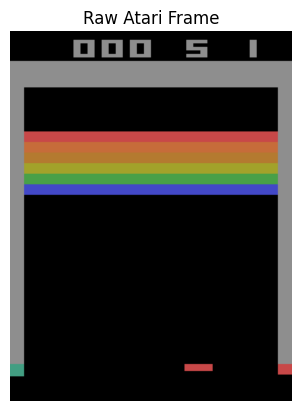

In [18]:
import matplotlib.pyplot as plt

env = gym.make("ALE/Breakout-v5")

obs, info = env.reset()

plt.imshow(obs)
plt.title("Raw Atari Frame")
plt.axis("off")
plt.show()

Display preprocessed frame

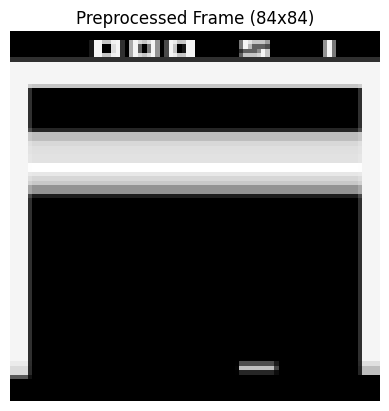

In [19]:
processed = preprocess_frame(obs)

plt.imshow(processed, cmap="gray")
plt.title("Preprocessed Frame (84x84)")
plt.axis("off")
plt.show()

Verify Shapes

In [20]:
print("Raw shape:", obs.shape)
print("Processed shape:", processed.shape)

Raw shape: (210, 160, 3)
Processed shape: (84, 84)


Visualise Frame Stack

In [21]:
stacker = FrameStack()

obs, _ = env.reset()

state = stacker.reset(obs)

print(state.shape)

(4, 84, 84)


Plot all 4 frames

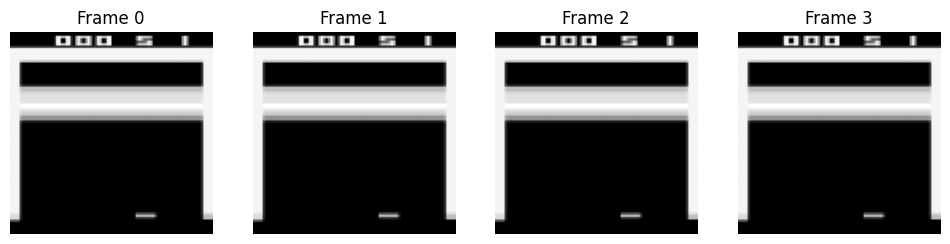

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(12,3))

for i in range(4):
    axes[i].imshow(state[i], cmap="gray")
    axes[i].set_title(f"Frame {i}")
    axes[i].axis("off")

plt.show()

Take some Random actions

In [23]:
for _ in range(10):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    state = stacker.append(obs)

    if terminated or truncated:
        obs, _ = env.reset()
        state = stacker.reset(obs)

New frames

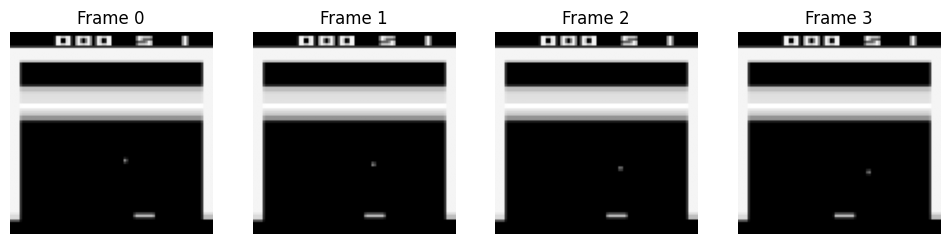

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(12,3))

for i in range(4):
    axes[i].imshow(state[i], cmap="gray")
    axes[i].set_title(f"Frame {i}")
    axes[i].axis("off")

plt.show()

Verify State Ready for CNN

In [25]:
print(state.shape)
print(state.dtype)
print(state.min())
print(state.max())

(4, 84, 84)
float64
0.0
0.5803921568627451


# Replay Buffer

ReplayBuffer Class

In [34]:
import random
import numpy as np
from collections import deque

class ReplayBuffer:

    def __init__(self, capacity):

        self.buffer = deque(maxlen=capacity)

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(self, batch_size):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.stack(states),
            np.array(actions),
            np.array(rewards),
            np.stack(next_states),
            np.array(dones)
        )

    def __len__(self):

        return len(self.buffer)

Create Buffer

In [35]:
buffer = ReplayBuffer(
    capacity=100000
)

Add dummy data

In [36]:
state = np.zeros((4,84,84))

next_state = np.ones((4,84,84))

buffer.add(
    state,
    2,
    1.0,
    next_state,
    False
)

print(len(buffer))

for i in range(100):

    buffer.add(
        np.random.rand(4,84,84),
        np.random.randint(4),
        np.random.rand(),
        np.random.rand(4,84,84),
        False
    )

print(len(buffer))

1
101


Sample batch and check shape

In [37]:
states, actions, rewards, next_states, dones = buffer.sample(batch_size=32)

print(states.shape)
print(actions.shape)
print(rewards.shape)
print(next_states.shape)
print(dones.shape)

(32, 4, 84, 84)
(32,)
(32,)
(32, 4, 84, 84)
(32,)


Testing with real breakout data

In [38]:
buffer = ReplayBuffer(1000)

env = gym.make("ALE/Breakout-v5")

stacker = FrameStack()

obs, _ = env.reset()

state = stacker.reset(obs)


for _ in range(100):

    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, info = env.step(action)

    next_state = stacker.append(next_obs)

    done = terminated or truncated

    buffer.add(
        state,
        action,
        reward,
        next_state,
        done
    )

    state = next_state

    if done:
        obs, _ = env.reset()
        state = stacker.reset(obs)

Sample batch

In [39]:
states, actions, rewards, next_states, dones = buffer.sample(32)

print(states.shape)

(32, 4, 84, 84)
